# CNN model (updated)

In [43]:
from pathlib import Path
import random

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from quickdraw import QuickDrawDataGroup

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [44]:
SEED = 42
SAMPLES_PER_CATEGORY = 1000
IMAGE_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.001
EMBEDDING_SIZE = 128

CATEGORY_FILE = Path("../../data/categories/objects.txt")
RESULTS_DIR = Path("objects_cnn_embedding_results")
RESULTS_DIR.mkdir(exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Setup complete")

Setup complete


## Load category names

The category file contains the everyday object labels that this CNN will learn to classify.

In [45]:
with open(CATEGORY_FILE, "r") as f:
    text = f.read()

categories = [
    category.strip()
    for category in text.replace("\n", ",").split(",")
    if category.strip()
]

label_map = {category: index for index, category in enumerate(categories)}
reverse_label_map = {index: category for category, index in label_map.items()}

print("Number of categories:", len(categories))
print(categories)

Number of categories: 15
['backpack', 'bed', 'book', 'chair', 'clock', 'cup', 'door', 'key', 'knife', 'laptop', 'shoe', 'spoon', 'table', 'television', 'toothbrush']


## Convert drawings into image arrays

In [46]:
def drawing_to_array(drawing, image_size=IMAGE_SIZE):
    image = drawing.image
    
    # Convert to grayscale
    image = image.convert("L")
    
    # Resize to 64x64
    image = image.resize((image_size, image_size), Image.Resampling.LANCZOS)
    
    # Convert image to numpy array
    array = np.array(image).astype(np.float32)
    
    # Invert so black drawing lines become bright values
    array = 255.0 - array
    
    # Normalize from 0-255 to 0-1
    array = array / 255.0
    
    return array

## Build dataset


In [47]:
X = []
y = []

for category in categories:
    print(f"Loading {category}...")
    
    group = QuickDrawDataGroup(
        category,
        max_drawings=SAMPLES_PER_CATEGORY,
        print_messages=False
    )
    
    count = 0
    
    for drawing in group.drawings:
        array = drawing_to_array(drawing, IMAGE_SIZE)
        
        X.append(array)
        y.append(label_map[category])
        
        count += 1
        
        if count >= SAMPLES_PER_CATEGORY:
            break
    
    print(f"Loaded {count} drawings for {category}")

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int64)

print("X shape:", X.shape)
print("y shape:", y.shape)

Loading backpack...
Loaded 1000 drawings for backpack
Loading bed...
Loaded 1000 drawings for bed
Loading book...
Loaded 1000 drawings for book
Loading chair...
Loaded 1000 drawings for chair
Loading clock...
Loaded 1000 drawings for clock
Loading cup...
Loaded 1000 drawings for cup
Loading door...
Loaded 1000 drawings for door
Loading key...
Loaded 1000 drawings for key
Loading knife...
Loaded 1000 drawings for knife
Loading laptop...
Loaded 1000 drawings for laptop
Loading shoe...
Loaded 1000 drawings for shoe
Loading spoon...
Loaded 1000 drawings for spoon
Loading table...
Loaded 1000 drawings for table
Loading television...
Loaded 1000 drawings for television
Loading toothbrush...
Loaded 1000 drawings for toothbrush
X shape: (15000, 128, 128)
y shape: (15000,)


## Preview drawings

Before training, we check a few examples to make sure the images loaded correctly.

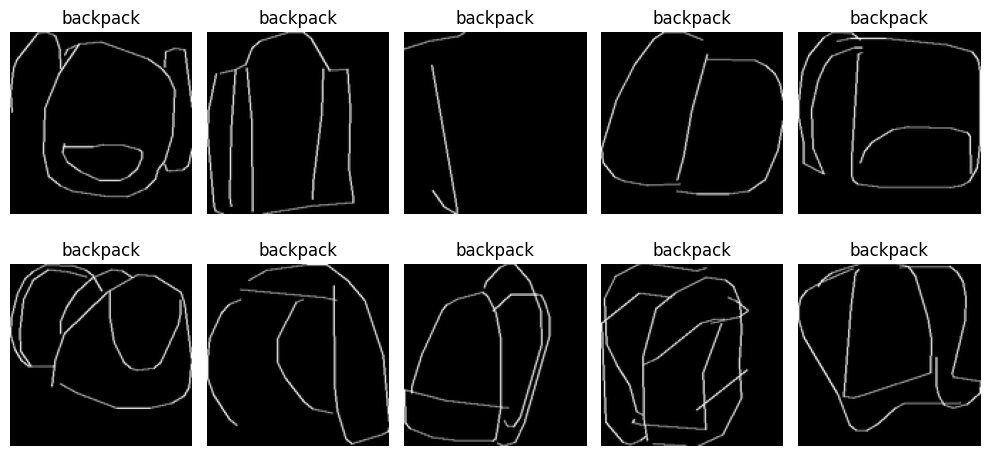

In [48]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i], cmap="gray")
    plt.title(reverse_label_map[y[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Prepare CNN data

PyTorch CNNs expect image data in this format:

`number of images, color channels, height, width`

Since these are grayscale images, the number of channels is 1.

In [49]:
# Add channel dimension: (samples, 1, 128, 128)
X_cnn = X[:, np.newaxis, :, :]

X_train, X_test, y_train, y_test = train_test_split(
    X_cnn,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training data:", X_train_tensor.shape)
print("Testing data:", X_test_tensor.shape)

Training data: torch.Size([12000, 1, 128, 128])
Testing data: torch.Size([3000, 1, 128, 128])


## Define the CNN model

This simple CNN has:

- 2 convolution layers
- 2 max pooling layers
- 1 flatten layer
- 1 embedding layer that creates a 128-dimensional feature vector
- 1 final classification layer

In [50]:
class EmbeddingObjectCNN(nn.Module):
    def __init__(self, num_classes, embedding_size=128):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten()
        )

        # 128x128 becomes 64x64 after first pooling,
        # then 32x32 after second pooling.
        self.embedding = nn.Sequential(
            nn.Linear(32 * 32 * 32, embedding_size),
            nn.ReLU()
        )

        self.classifier = nn.Linear(embedding_size, num_classes)

    def forward(self, x):
        features = self.features(x)
        embedding = self.embedding(features)
        output = self.classifier(embedding)
        return output

    def get_embedding(self, x):
        features = self.features(x)
        embedding = self.embedding(features)
        return embedding

In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EmbeddingObjectCNN(
    num_classes=len(categories),
    embedding_size=EMBEDDING_SIZE
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("Using device:", device)
print(model)

Using device: cpu
EmbeddingObjectCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
  )
  (embedding): Sequential(
    (0): Linear(in_features=32768, out_features=128, bias=True)
    (1): ReLU()
  )
  (classifier): Linear(in_features=128, out_features=15, bias=True)
)


## Train the CNN

In [52]:
train_losses = []
train_accuracies = []
test_accuracies = []

best_accuracy = 0
best_epoch = 0
best_model_state = None

for epoch in range(EPOCHS):

    # Training
    model.train()
    
    total_loss = 0
    train_correct = 0
    train_total = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        train_predictions = torch.argmax(outputs, dim=1)
        train_correct += (train_predictions == labels).sum().item()
        train_total += labels.size(0)
    
    average_loss = total_loss / len(train_loader)
    train_accuracy = train_correct / train_total
    
    # Testing
    model.eval()
    
    test_correct = 0
    test_total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            test_predictions = torch.argmax(outputs, dim=1)
            
            test_correct += (test_predictions == labels).sum().item()
            test_total += labels.size(0)
    
    test_accuracy = test_correct / test_total
    
    train_losses.append(average_loss)
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)
    
    # Save the best model based on test accuracy
    if test_accuracy > best_accuracy:
        best_accuracy = test_accuracy
        best_epoch = epoch + 1
        best_model_state = {
            key: value.cpu().clone()
            for key, value in model.state_dict().items()
        }
    
    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Loss: {average_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f} | "
        f"Test Accuracy: {test_accuracy:.4f}"
    )

# Load the best model after training finishes
model.load_state_dict(best_model_state)

cnn_accuracy = best_accuracy

print("\nTraining complete!")
print(f"Best epoch: {best_epoch}")
print(f"Best CNN test accuracy: {cnn_accuracy:.4f}")
print(f"Best CNN test accuracy percentage: {cnn_accuracy * 100:.2f}%")

Epoch 1/10 | Loss: 1.4424 | Train Accuracy: 0.5553 | Test Accuracy: 0.7147
Epoch 2/10 | Loss: 0.6646 | Train Accuracy: 0.8000 | Test Accuracy: 0.7557
Epoch 3/10 | Loss: 0.3591 | Train Accuracy: 0.8930 | Test Accuracy: 0.7507
Epoch 4/10 | Loss: 0.1803 | Train Accuracy: 0.9473 | Test Accuracy: 0.7480
Epoch 5/10 | Loss: 0.0783 | Train Accuracy: 0.9772 | Test Accuracy: 0.7567
Epoch 6/10 | Loss: 0.0560 | Train Accuracy: 0.9836 | Test Accuracy: 0.7493
Epoch 7/10 | Loss: 0.0324 | Train Accuracy: 0.9917 | Test Accuracy: 0.7557
Epoch 8/10 | Loss: 0.0493 | Train Accuracy: 0.9842 | Test Accuracy: 0.7423
Epoch 9/10 | Loss: 0.0491 | Train Accuracy: 0.9842 | Test Accuracy: 0.7403
Epoch 10/10 | Loss: 0.0249 | Train Accuracy: 0.9922 | Test Accuracy: 0.7493

Training complete!
Best epoch: 5
Best CNN test accuracy: 0.7567
Best CNN test accuracy percentage: 75.67%


In [53]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        
        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)
        
        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())

cnn_accuracy = accuracy_score(all_labels, all_predictions)

print(f"Final CNN accuracy: {cnn_accuracy:.4f}")

Final CNN accuracy: 0.7567


## Extract embeddings from CNN

This section runs all dataset images through the CNN and extracts the 128-dimensional embeddings from the layer before classification.

In [54]:
# Prepare the full dataset for embedding extraction
X_all_cnn = X[:, np.newaxis, :, :]
X_all_tensor = torch.tensor(X_all_cnn, dtype=torch.float32)

all_dataset = TensorDataset(X_all_tensor, torch.tensor(y, dtype=torch.long))
all_loader = DataLoader(all_dataset, batch_size=BATCH_SIZE, shuffle=False)

all_embeddings = []
all_embedding_labels = []

model.eval()

with torch.no_grad():
    for images, labels in all_loader:
        images = images.to(device)

        embeddings = model.get_embedding(images)

        all_embeddings.append(embeddings.cpu().numpy())
        all_embedding_labels.append(labels.numpy())

all_embeddings = np.vstack(all_embeddings)
all_embedding_labels = np.concatenate(all_embedding_labels)

print("Embeddings shape:", all_embeddings.shape)
print("Labels shape:", all_embedding_labels.shape)

Embeddings shape: (15000, 128)
Labels shape: (15000,)


In [55]:
EMBEDDINGS_DIR = Path("../../data/embeddings")
EMBEDDINGS_DIR.mkdir(parents=True, exist_ok=True)

embedding_path = EMBEDDINGS_DIR / "objects_embeddings.npz"

np.savez(
    embedding_path,
    embeddings=all_embeddings,
    labels=all_embedding_labels,
    categories=np.array(categories),
    embedding_size=EMBEDDING_SIZE,
    image_size=IMAGE_SIZE,
    samples_per_category=SAMPLES_PER_CATEGORY,
    best_accuracy=cnn_accuracy
)

print("Saved embeddings to:", embedding_path)

Saved embeddings to: ../../data/embeddings/objects_embeddings.npz


In [56]:
# first embedding vector
example_index = 0

print("Class label:", reverse_label_map[all_embedding_labels[example_index]])
print("Embedding vector shape:", all_embeddings[example_index].shape)
print("First 20 embedding values:")
print(all_embeddings[example_index][:20])

Class label: backpack
Embedding vector shape: (128,)
First 20 embedding values:
[ 0.        0.        0.       29.540905  0.        0.        0.
  0.       24.182648  0.       22.11089   0.        0.        0.
  0.        0.        0.        0.        0.        0.      ]


In [57]:
# Embedding summary by class

embedding_summary = []

for class_index, class_name in reverse_label_map.items():
    class_embeddings = all_embeddings[all_embedding_labels == class_index]
    
    embedding_summary.append({
        "class": class_name,
        "num_embeddings": class_embeddings.shape[0],
        "embedding_dimension": class_embeddings.shape[1],
        "mean_value": class_embeddings.mean(),
        "std_value": class_embeddings.std(),
        "min_value": class_embeddings.min(),
        "max_value": class_embeddings.max()
    })

embedding_summary_df = pd.DataFrame(embedding_summary)
embedding_summary_df

,class,num_embeddings,embedding_dimension,mean_value,std_value,min_value,max_value
0,backpack,1000,128,2.788485,8.132468,0.0,91.409706
1,bed,1000,128,2.489164,6.518842,0.0,84.819595
2,book,1000,128,2.835544,8.037081,0.0,83.182785
3,chair,1000,128,2.397676,6.328341,0.0,84.331589
4,clock,1000,128,2.619967,7.936173,0.0,77.796974
5,cup,1000,128,2.392972,6.700707,0.0,75.391068
6,door,1000,128,2.458515,6.552298,0.0,79.443100
7,key,1000,128,2.092302,6.286990,0.0,74.941528
8,knife,1000,128,2.268949,6.243422,0.0,67.558151
9,laptop,1000,128,2.933627,8.246480,0.0,96.334450


## Compute class centroids

For each class, this section computes:

- k=1 centroid using the mean embedding
- k=5 centroids using KMeans
- k=10 centroids using KMeans

In [58]:
from sklearn.cluster import KMeans

centroids_by_k = {}

for k in [1, 5, 10]:
    centroids_by_k[k] = {}

    for class_index, class_name in reverse_label_map.items():
        class_embeddings = all_embeddings[all_embedding_labels == class_index]

        if k == 1:
            centroids = class_embeddings.mean(axis=0, keepdims=True)
        else:
            kmeans = KMeans(
                n_clusters=k,
                random_state=SEED,
                n_init=10
            )
            kmeans.fit(class_embeddings)
            centroids = kmeans.cluster_centers_

        centroids_by_k[k][class_name] = centroids

    print(f"Finished k={k} centroids")

Finished k=1 centroids
Finished k=5 centroids
Finished k=10 centroids


In [59]:
CENTROIDS_DIR = Path("../../data/centroids")
CENTROIDS_DIR.mkdir(parents=True, exist_ok=True)

for k, centroid_dict in centroids_by_k.items():
    save_path = CENTROIDS_DIR / f"objects_{k}.npz"
    
    np.savez(
        save_path,
        centroids=centroid_dict,
        categories=np.array(categories),
        embedding_size=EMBEDDING_SIZE,
        image_size=IMAGE_SIZE,
        samples_per_category=SAMPLES_PER_CATEGORY,
        best_accuracy=cnn_accuracy
    )
    
    print("Saved:", save_path)

Saved: ../../data/centroids/objects_1.npz
Saved: ../../data/centroids/objects_5.npz
Saved: ../../data/centroids/objects_10.npz


## Load good and bad evaluation drawings

This section loads one good and one bad drawing for each object class.

The drawings are stored in:

`../../data/base_drawings/objects/`

Each file should be named like:

- `chair_good.png`
- `chair_bad.png`

In [60]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

BASE_DRAWINGS_DIR = Path("../../data/base_drawings/objects")

print("Base drawings folder:", BASE_DRAWINGS_DIR.resolve())

Base drawings folder: /Users/nghi_nguyen/Desktop/su26-ai-team-3/data/base_drawings/objects


In [61]:
missing_files = []
drawing_paths = {}

for class_name in categories:
    for quality in ["good", "bad"]:
        possible_paths = [
            BASE_DRAWINGS_DIR / f"{class_name}_{quality}.png",
            BASE_DRAWINGS_DIR / f"{class_name}_{quality}.jpg",
            BASE_DRAWINGS_DIR / f"{class_name}_{quality}.jpeg",
            BASE_DRAWINGS_DIR / f"{class_name}_{quality}.PNG",
            BASE_DRAWINGS_DIR / f"{class_name}_{quality}.JPG",
            BASE_DRAWINGS_DIR / f"{class_name}_{quality}.JPEG",
        ]
        
        found_path = None
        
        for path in possible_paths:
            if path.exists():
                found_path = path
                break
        
        if found_path is None:
            missing_files.append(f"{class_name}_{quality}")
        else:
            drawing_paths[(class_name, quality)] = found_path

if missing_files:
    print("Missing drawings:")
    for item in missing_files:
        print(item)
else:
    print("All good/bad drawing files found!")

All good/bad drawing files found!


In [62]:
def load_eval_image(image_path, image_size=128):
    image = Image.open(image_path).convert("L")
    image = image.resize((image_size, image_size), Image.Resampling.LANCZOS)

    array = np.array(image).astype(np.float32)

    # Invert so black/dark drawing lines become bright values
    array = 255.0 - array

    # Normalize to 0-1
    array = array / 255.0

    # Add CNN dimensions: (1, 1, 128, 128)
    array = array[np.newaxis, np.newaxis, :, :]

    return torch.tensor(array, dtype=torch.float32)

In [63]:
eval_embeddings = []

model.eval()

with torch.no_grad():
    for class_name in categories:
        for quality in ["good", "bad"]:
            image_path = drawing_paths[(class_name, quality)]
            
            image_tensor = load_eval_image(image_path, IMAGE_SIZE).to(device)
            
            embedding = model.get_embedding(image_tensor)
            embedding = embedding.cpu().numpy()
            
            eval_embeddings.append({
                "class": class_name,
                "quality": quality,
                "file_path": str(image_path),
                "embedding": embedding
            })

print("Number of eval embeddings:", len(eval_embeddings))

Number of eval embeddings: 30


In [64]:
report_rows = []

for item in eval_embeddings:
    class_name = item["class"]
    quality = item["quality"]
    drawing_embedding = item["embedding"]  # shape: (1, 128)

    for k in [1, 5, 10]:
        centroids = centroids_by_k[k][class_name]  # shape: (k, 128)

        similarities = cosine_similarity(drawing_embedding, centroids)

        average_similarity = similarities.mean()
        max_similarity = similarities.max()

        report_rows.append({
            "class": class_name,
            "quality": quality,
            "k_centroids": k,
            "average_cosine_similarity": average_similarity,
            "max_cosine_similarity": max_similarity
        })

cosine_report = pd.DataFrame(report_rows)

print("Report shape:", cosine_report.shape)
cosine_report.head()

Report shape: (90, 5)


,class,quality,k_centroids,average_cosine_similarity,max_cosine_similarity
0,backpack,good,1,0.389329,0.389329
1,backpack,good,5,0.383562,0.496138
2,backpack,good,10,0.374043,0.504283
3,backpack,bad,1,0.541642,0.541642
4,backpack,bad,5,0.528103,0.635141


In [65]:
cosine_report

,class,quality,k_centroids,average_cosine_similarity,max_cosine_similarity
0,backpack,good,1,0.389329,0.389329
1,backpack,good,5,0.383562,0.496138
2,backpack,good,10,0.374043,0.504283
3,backpack,bad,1,0.541642,0.541642
4,backpack,bad,5,0.528103,0.635141
...,...,...,...,...,...
85,toothbrush,good,5,0.443672,0.538391
86,toothbrush,good,10,0.420801,0.534423
87,toothbrush,bad,1,0.367872,0.367872
88,toothbrush,bad,5,0.315464,0.363313


In [66]:
summary = cosine_report.groupby(["quality", "k_centroids"])[
    ["average_cosine_similarity", "max_cosine_similarity"]
].mean()

summary

average_cosine_similarity  max_cosine_similarity
quality k_centroids                                                  
bad     1                             0.478449               0.478449
        5                             0.455214               0.545117
        10                            0.443859               0.578089
good    1                             0.508388               0.508388
        5                             0.480815               0.587119
        10                            0.470875               0.605890

In [67]:
REPORTS_DIR = Path("../../data/reports")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

report_path = REPORTS_DIR / "objects_cosine_similarity_report.csv"

cosine_report.to_csv(report_path, index=False)

print("Saved cosine similarity report to:", report_path)

Saved cosine similarity report to: ../../data/reports/objects_cosine_similarity_report.csv
